# DS4SE26 Week 3 — ARC Clustering on PC2 / Slurm Kernel

This notebook is split into separate cells so you can debug each stage cleanly.

It fixes the `ModuleNotFoundError: pandas` issue by:

1. Installing packages into your user environment with the **same Python executable used by the notebook kernel**.
2. Adding `~/.local/bin` to `PATH`, so PC2 warnings about scripts like `huggingface-cli`, `torchrun`, `tqdm`, etc. stop mattering.
3. Adding your Python user-site package folder to `sys.path`, so imports like `pandas` are visible immediately.

Expected input folder structure in the same directory as this notebook:

```text
input/
  lucene-codecs-focused.rsf
  wca_uem.rsf
  wca_uemnm.rsf
  limbo_il.rsf
```

Main output:

```text
output/ARC_Qodo_alpha0_5_k10_clusters.rsf
```


## Cell 1 — Fix PATH and Python user-site visibility

Run this first. This addresses the PC2 warnings about scripts being installed in `~/.local/bin` but not being on `PATH`. These warnings are usually not fatal for imports, but this cell fixes them anyway.

In [1]:
import os
from pathlib import Path

WORK_DIR = Path.cwd().resolve()

os.environ["HF_HOME"] = f"/scratch/hpc-prf-dssecs/{os.environ['USER']}/hf_cache"
os.environ["HF_HUB_CACHE"] = f"/scratch/hpc-prf-dssecs/{os.environ['USER']}/hf_cache/hub"
os.environ["TRANSFORMERS_CACHE"] = f"/scratch/hpc-prf-dssecs/{os.environ['USER']}/hf_cache/transformers"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("WORK_DIR:", WORK_DIR)
print("HF_HOME:", os.environ["HF_HOME"])

WORK_DIR: /pc2/users/r/rohit
HF_HOME: /scratch/hpc-prf-dssecs/rohit/hf_cache


In [2]:
# ============================================================
# CELL 1 — FIX PATH AND PYTHON USER-SITE VISIBILITY
# ============================================================
import os
import sys
import site
from pathlib import Path

USER_BIN = Path.home() / ".local" / "bin"
os.environ["PATH"] = str(USER_BIN) + os.pathsep + os.environ.get("PATH", "")

try:
    USER_SITE = site.getusersitepackages()
except Exception:
    USER_SITE = None

if USER_SITE and USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Added to PATH:", USER_BIN)
print("User site-packages:", USER_SITE)
print("Is user site on sys.path?", USER_SITE in sys.path if USER_SITE else "unknown")
print("PATH begins with:", os.environ["PATH"].split(os.pathsep)[:3])

Python executable: /pc2/software/JUPYTER/n2/bin/python3
Python version: 3.10.14 (main, Mar 21 2024, 16:24:04) [GCC 11.2.0]
Added to PATH: /pc2/users/r/rohit/.local/bin
User site-packages: /pc2/users/r/rohit/.local/lib/python3.10/site-packages
Is user site on sys.path? True
PATH begins with: ['/pc2/users/r/rohit/.local/bin', '/opt/software/pc2/EB-SW/software/code-server/4.22.1/bin', '/pc2/software/JUPYTER/n2/bin']


## Cell 2 — Install required packages

This cell installs everything into your user environment using the current notebook kernel's Python.

If imports still fail after this cell, restart the kernel once and run from Cell 1 again.

In [3]:
# ============================================================
# CELL 2 — INSTALL REQUIRED PACKAGES ROBUSTLY
# ============================================================
import os
import sys
import site
import subprocess
import importlib
from pathlib import Path

USER_BIN = Path.home() / ".local" / "bin"
os.environ["PATH"] = str(USER_BIN) + os.pathsep + os.environ.get("PATH", "")

try:
    USER_SITE = site.getusersitepackages()
    if USER_SITE not in sys.path:
        sys.path.insert(0, USER_SITE)
except Exception:
    USER_SITE = None

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "scipy",
    "torch",
    "transformers",
    "accelerate",
    "sentence-transformers",
    "huggingface_hub",
]

print("Installing/checking packages using:", sys.executable)
print("User site:", USER_SITE)

cmd = [
    sys.executable, "-m", "pip", "install",
    "--user",
    "--upgrade",
    "--no-warn-script-location",
] + packages

print("Running:", " ".join(cmd))
subprocess.check_call(cmd)

importlib.invalidate_caches()

try:
    USER_SITE = site.getusersitepackages()
    if USER_SITE not in sys.path:
        sys.path.insert(0, USER_SITE)
except Exception:
    pass

print("\nInstallation finished.")
print("If the next import cell still fails, restart kernel once and rerun from Cell 1.")

Installing/checking packages using: /pc2/software/JUPYTER/n2/bin/python3
User site: /pc2/users/r/rohit/.local/lib/python3.10/site-packages
Running: /pc2/software/JUPYTER/n2/bin/python3 -m pip install --user --upgrade --no-warn-script-location numpy pandas matplotlib scikit-learn scipy torch transformers accelerate sentence-transformers huggingface_hub

Installation finished.
If the next import cell still fails, restart kernel once and rerun from Cell 1.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Cell 3 — Verify imports and GPU

This checks that `pandas` and the other libraries are now visible to the kernel.

In [4]:
# ============================================================
# CELL 3 — VERIFY IMPORTS AND GPU
# ============================================================
import os
import sys
import site
from pathlib import Path

USER_BIN = Path.home() / ".local" / "bin"
os.environ["PATH"] = str(USER_BIN) + os.pathsep + os.environ.get("PATH", "")

try:
    USER_SITE = site.getusersitepackages()
    if USER_SITE not in sys.path:
        sys.path.insert(0, USER_SITE)
except Exception:
    USER_SITE = None

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import sklearn
import transformers
import sentence_transformers

print("All imports successful.")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)

print("\nCUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

/pc2/users/r/rohit/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.
numpy: 2.2.6
pandas: 2.3.3
torch: 2.12.0+cu130
sklearn: 1.7.2
transformers: 5.8.1
sentence-transformers: 5.5.0

CUDA available: False
GPU count: 0


/pc2/users/r/rohit/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/pc2/users/r/rohit/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:1074: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


## Cell 4 — Set folders, files, model, and ARC parameters

Change `LUCENE_GIT_TAG` only if your Week 1 RSF was made from a different Lucene version.

In [5]:
# ============================================================
# CELL 4 — CONFIGURATION
# ============================================================
import os
import sys
import re
import time
import json
import csv
import math
import shutil
import getpass
import subprocess
from pathlib import Path
from collections import defaultdict

WORK_DIR = Path.cwd().resolve()

INPUT_DIR = WORK_DIR / "input"
OUTPUT_DIR = WORK_DIR / "output"
CACHE_DIR = WORK_DIR / "cache"
SRC_DIR = WORK_DIR / "src"
LOG_DIR = WORK_DIR / "logs"

for d in [INPUT_DIR, OUTPUT_DIR, CACHE_DIR, SRC_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Required input files
FOCUSED_DEPENDENCY_RSF = INPUT_DIR / "lucene-codecs-focused.rsf"

BASELINE_CLUSTER_FILES = {
    "WCA_UEM": INPUT_DIR / "wca_uem.rsf",
    "WCA_UEMNM": INPUT_DIR / "wca_uemnm.rsf",
    "LIMBO_IL": INPUT_DIR / "limbo_il.rsf",
}

# Week 3 model for Groups 4/9/14
EMBEDDING_MODEL_NAME = "Qodo/Qodo-Embed-1-7B"

# Keep this aligned with your Week 1 RSF version if possible.
LUCENE_GIT_TAG = "releases/lucene/9.10.0"

# ARC settings
ALPHA = 0.50
TARGET_NUM_CLUSTERS = 10
BATCH_SIZE = 2
MAX_TOKENS = 8192

RUN_NAME = f"ARC_Qodo_alpha{str(ALPHA).replace('.', '_')}_k{TARGET_NUM_CLUSTERS}"
ARC_RSF_OUT = OUTPUT_DIR / f"{RUN_NAME}_clusters.rsf"
ARC_CSV_OUT = OUTPUT_DIR / f"{RUN_NAME}_clusters.csv"
COMPARISON_CSV_OUT = OUTPUT_DIR / f"{RUN_NAME}_python_comparison_sanity.csv"
SUMMARY_OUT = OUTPUT_DIR / f"{RUN_NAME}_summary.txt"

# HF/model cache location
os.environ["HF_HOME"] = str(CACHE_DIR / "hf_cache")
os.environ["HF_HUB_CACHE"] = str(CACHE_DIR / "hf_cache" / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(CACHE_DIR / "hf_cache" / "transformers")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("Working directory:", WORK_DIR)
print("Input directory:", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Cache directory:", CACHE_DIR)
print("Model:", EMBEDDING_MODEL_NAME)
print("Lucene tag:", LUCENE_GIT_TAG)
print("ALPHA:", ALPHA)
print("TARGET_NUM_CLUSTERS:", TARGET_NUM_CLUSTERS)

Working directory: /pc2/users/r/rohit
Input directory: /pc2/users/r/rohit/input
Output directory: /pc2/users/r/rohit/output
Cache directory: /pc2/users/r/rohit/cache
Model: Qodo/Qodo-Embed-1-7B
Lucene tag: releases/lucene/9.10.0
ALPHA: 0.5
TARGET_NUM_CLUSTERS: 10


In [6]:
from pathlib import Path
import os

WORK_DIR = Path.cwd().resolve()
INPUT_DIR = WORK_DIR / "input"

print("Current notebook working directory:")
print(WORK_DIR)

print("\nDoes input folder exist?")
print(INPUT_DIR.exists(), INPUT_DIR)

print("\nFiles in current folder:")
for p in sorted(WORK_DIR.iterdir()):
    print(" -", p.name)

print("\nRSF files found anywhere under this folder:")
rsf_files = list(WORK_DIR.rglob("*.rsf"))
if rsf_files:
    for p in rsf_files:
        print(" -", p.relative_to(WORK_DIR))
else:
    print("No .rsf files found.")

Current notebook working directory:
/pc2/users/r/rohit

Does input folder exist?
True /pc2/users/r/rohit/input

Files in current folder:
 - .bash_history
 - .bash_logout
 - .bash_profile
 - .bashrc
 - .cache
 - .config
 - .esd_auth
 - .ipynb_checkpoints
 - .ipython
 - .local
 - .npm
 - .vimrc
 - .zshrc
 - DS4SE26_Week3_ARC_PC2_MultiCell_Fixed.ipynb
 - DS4SE26_Week3_ARC_PC2_Slurm_Ready.ipynb
 - Untitled.ipynb
 - cache
 - input
 - logs
 - output
 - src

RSF files found anywhere under this folder:
 - input/wca_uem.rsf
 - input/wca uemnm.rsf
 - input/limbo il.rsf
 - input/Lucene_codecs_focused.rsf
 - input/limbo_il.rsf
 - input/wca_uemnm.rsf
 - input/wca uem.rsf
 - input/.ipynb_checkpoints/Lucene_codecs_focused-checkpoint.rsf


In [7]:
from pathlib import Path
import shutil

WORK_DIR = Path.cwd().resolve()
INPUT_DIR = WORK_DIR / "input"
INPUT_DIR.mkdir(exist_ok=True)

print("Working directory:", WORK_DIR)
print("Input directory:", INPUT_DIR)

# Find all RSF files under current notebook folder
all_rsf = list(WORK_DIR.rglob("*.rsf"))

print("\nFound RSF files:")
for p in all_rsf:
    print(" -", p.relative_to(WORK_DIR))

# Expected final filenames
expected = {
    "focused": INPUT_DIR / "lucene-codecs-focused.rsf",
    "wca_uem": INPUT_DIR / "wca_uem.rsf",
    "wca_uemnm": INPUT_DIR / "wca_uemnm.rsf",
    "limbo_il": INPUT_DIR / "limbo_il.rsf",
}

# Auto-detect based on old filenames / folder names
def find_file(keywords):
    for p in all_rsf:
        name = str(p).lower()
        if all(k.lower() in name for k in keywords):
            return p
    return None

candidates = {
    "focused": find_file(["focused"]) or find_file(["filter"]) or find_file(["codecs"]),
    "wca_uem": find_file(["uem"]) if not find_file(["uemnm"]) else None,
    "wca_uemnm": find_file(["uemnm"]),
    "limbo_il": find_file(["limbo"]) or find_file(["il"]),
}

# Better WCA_UEM detection: file containing UEM but not UEMNM
for p in all_rsf:
    name = str(p).lower()
    if "uem" in name and "uemnm" not in name:
        candidates["wca_uem"] = p

print("\nDetected candidates:")
for label, path in candidates.items():
    print(label, "=>", path.relative_to(WORK_DIR) if path else "NOT FOUND")

# Copy detected files to expected names
for label, src in candidates.items():
    dst = expected[label]
    if src and src.exists():
        if src.resolve() != dst.resolve():
            shutil.copy2(src, dst)
            print(f"Copied {src.name} -> input/{dst.name}")
        else:
            print(f"Already correct: input/{dst.name}")
    else:
        print(f"Could not auto-detect: {dst.name}")

print("\nFinal input folder contents:")
for p in sorted(INPUT_DIR.glob("*")):
    print(" -", p.name)

Working directory: /pc2/users/r/rohit
Input directory: /pc2/users/r/rohit/input

Found RSF files:
 - input/wca_uem.rsf
 - input/wca uemnm.rsf
 - input/limbo il.rsf
 - input/Lucene_codecs_focused.rsf
 - input/limbo_il.rsf
 - input/wca_uemnm.rsf
 - input/wca uem.rsf
 - input/.ipynb_checkpoints/Lucene_codecs_focused-checkpoint.rsf

Detected candidates:
focused => input/Lucene_codecs_focused.rsf
wca_uem => input/wca uem.rsf
wca_uemnm => input/wca uemnm.rsf
limbo_il => input/limbo il.rsf
Copied Lucene_codecs_focused.rsf -> input/lucene-codecs-focused.rsf
Copied wca uem.rsf -> input/wca_uem.rsf
Copied wca uemnm.rsf -> input/wca_uemnm.rsf
Copied limbo il.rsf -> input/limbo_il.rsf

Final input folder contents:
 - .ipynb_checkpoints
 - Lucene_codecs_focused.rsf
 - limbo il.rsf
 - limbo_il.rsf
 - lucene-codecs-focused.rsf
 - wca uem.rsf
 - wca uemnm.rsf
 - wca_uem.rsf
 - wca_uemnm.rsf


## Cell 5 — Check required input files

This must pass before continuing.

In [8]:
# ============================================================
# CELL 5 — INPUT FILE CHECK
# ============================================================
missing = []

if not FOCUSED_DEPENDENCY_RSF.exists():
    missing.append(str(FOCUSED_DEPENDENCY_RSF))

for label, path in BASELINE_CLUSTER_FILES.items():
    if not path.exists():
        missing.append(str(path))

if missing:
    print("Missing required files:")
    for m in missing:
        print(" -", m)
    print("\nExpected folder structure:")
    print("input/lucene-codecs-focused.rsf")
    print("input/wca_uem.rsf")
    print("input/wca_uemnm.rsf")
    print("input/limbo_il.rsf")
    raise FileNotFoundError("Upload the missing files and rerun this cell.")
else:
    print("All required input files found.")
    print("Focused RSF:", FOCUSED_DEPENDENCY_RSF)
    for label, path in BASELINE_CLUSTER_FILES.items():
        print(f"{label}: {path}")

All required input files found.
Focused RSF: /pc2/users/r/rohit/input/lucene-codecs-focused.rsf
WCA_UEM: /pc2/users/r/rohit/input/wca_uem.rsf
WCA_UEMNM: /pc2/users/r/rohit/input/wca_uemnm.rsf
LIMBO_IL: /pc2/users/r/rohit/input/limbo_il.rsf


## Cell 6 — Hugging Face token

Paste your HF token when prompted. It will not be displayed.

In [9]:
# ============================================================
# CELL 6 — HUGGING FACE TOKEN
# ============================================================
import os
import getpass

if not os.environ.get("HF_TOKEN"):
    token = getpass.getpass("Paste HF_TOKEN: ").strip()
    if token:
        os.environ["HF_TOKEN"] = token
    else:
        print("WARNING: Empty HF_TOKEN. Model download may fail if the model is gated/private.")
else:
    print("HF_TOKEN already exists in environment.")

HF_TOKEN = os.environ.get("HF_TOKEN")

try:
    from huggingface_hub import login
    if HF_TOKEN:
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("Logged in to Hugging Face.")
except Exception as e:
    print("Hugging Face login warning:", repr(e))

Paste HF_TOKEN:  ········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to Hugging Face.


## Cell 7 — Clone or reuse Lucene source code

This gets the Java source files for Lucene Codecs.

In [10]:
# ============================================================
# CELL 7 — CLONE / REUSE LUCENE SOURCE CODE
# ============================================================
LUCENE_REPO_DIR = SRC_DIR / "lucene"

candidate_tags = [
    LUCENE_GIT_TAG,
    "lucene-9.10.0",
    "releases/lucene/9.10.0",
]

if not LUCENE_REPO_DIR.exists():
    cloned = False
    for tag in candidate_tags:
        print(f"Trying to clone Apache Lucene tag/branch: {tag}")
        cmd = [
            "git", "clone",
            "--depth", "1",
            "--branch", tag,
            "https://github.com/apache/lucene.git",
            str(LUCENE_REPO_DIR)
        ]
        try:
            subprocess.check_call(cmd)
            print("Lucene cloned successfully with:", tag)
            cloned = True
            break
        except subprocess.CalledProcessError:
            print("Clone failed for:", tag)
            if LUCENE_REPO_DIR.exists():
                shutil.rmtree(LUCENE_REPO_DIR)

    if not cloned:
        print("Tag clone failed. Cloning default branch as fallback.")
        subprocess.check_call([
            "git", "clone",
            "--depth", "1",
            "https://github.com/apache/lucene.git",
            str(LUCENE_REPO_DIR)
        ])
else:
    print("Lucene source already exists:", LUCENE_REPO_DIR)

SOURCE_ROOT_CANDIDATES = [
    LUCENE_REPO_DIR / "lucene" / "codecs" / "src" / "java",
    LUCENE_REPO_DIR / "lucene" / "codecs" / "src" / "main" / "java",
    LUCENE_REPO_DIR / "codecs" / "src" / "java",
    LUCENE_REPO_DIR / "codecs" / "src" / "main" / "java",
]

SOURCE_ROOT = None
for candidate in SOURCE_ROOT_CANDIDATES:
    if candidate.exists():
        SOURCE_ROOT = candidate
        break

if SOURCE_ROOT is None:
    print("Could not find source root. Checked:")
    for c in SOURCE_ROOT_CANDIDATES:
        print(" -", c)
    raise FileNotFoundError("Lucene codecs source root not found.")

print("Using source root:", SOURCE_ROOT)

Lucene source already exists: /pc2/users/r/rohit/src/lucene
Using source root: /pc2/users/r/rohit/src/lucene/lucene/codecs/src/java


## Cell 8 — Read Java source files

This extracts fully-qualified class names like `org.apache.lucene.codecs.X`.

In [11]:
# ============================================================
# CELL 8 — READ JAVA SOURCE FILES
# ============================================================
def extract_package(java_text):
    match = re.search(r"^\s*package\s+([a-zA-Z0-9_.]+)\s*;", java_text, flags=re.MULTILINE)
    return match.group(1) if match else None

def java_file_to_fqn(java_file):
    text = java_file.read_text(encoding="utf-8", errors="ignore")
    package = extract_package(text)
    if package:
        return f"{package}.{java_file.stem}"
    rel = java_file.relative_to(SOURCE_ROOT).with_suffix("")
    return ".".join(rel.parts)

java_files = sorted(SOURCE_ROOT.rglob("*.java"))

source_records = []
for jf in java_files:
    text = jf.read_text(encoding="utf-8", errors="ignore")
    fqn = java_file_to_fqn(jf)
    if fqn.startswith("org.apache.lucene.codecs"):
        source_records.append({
            "entity": fqn,
            "path": str(jf),
            "text": text,
        })

if not source_records:
    raise RuntimeError("No org.apache.lucene.codecs Java files found.")

entities = [r["entity"] for r in source_records]
texts = [r["text"] for r in source_records]
paths = [r["path"] for r in source_records]

print("Java source files used:", len(source_records))
print("First entity:", entities[0])
print("First path:", paths[0])

Java source files used: 93
First entity: org.apache.lucene.codecs.blockterms.BlockTermsReader
First path: /pc2/users/r/rohit/src/lucene/lucene/codecs/src/java/org/apache/lucene/codecs/blockterms/BlockTermsReader.java


## Cell 9 — Read focused dependency RSF

This reads the Week 1 filtered RSF with lines like:

```text
depends Source Target
```

In [12]:
# ============================================================
# CELL 9 — READ FOCUSED DEPENDENCY RSF
# ============================================================
def normalize_entity_name(x):
    x = x.strip().strip('"').strip("'").strip(",")
    x = x.replace("/", ".").replace("\\", ".")
    if x.endswith(".class"):
        x = x[:-6]
    # ARCADE/bytecode may use $ for inner classes. Keep outer-ish name comparable.
    x = x.replace("$", ".")
    return x

def parse_dependency_rsf(path):
    edges = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) >= 3 and parts[0].lower() == "depends":
                src = normalize_entity_name(parts[1])
                tgt = normalize_entity_name(parts[2])
                edges.append((src, tgt))
    return edges

dependency_edges = parse_dependency_rsf(FOCUSED_DEPENDENCY_RSF)

if not dependency_edges:
    raise RuntimeError("No dependency edges found. Check your RSF format.")

rsf_entities = set()
for s, t in dependency_edges:
    rsf_entities.add(s)
    rsf_entities.add(t)

source_entity_set = set(entities)
overlap_with_rsf = source_entity_set & rsf_entities

print("Dependency edges:", len(dependency_edges))
print("Unique RSF entities:", len(rsf_entities))
print("Source entities overlapping with RSF:", len(overlap_with_rsf), "/", len(source_entity_set))
print("Example edge:", dependency_edges[0])

if len(overlap_with_rsf) < max(5, 0.20 * len(source_entity_set)):
    print("\nWARNING: Low overlap between source files and focused RSF.")
    print("This usually means your Lucene source version does not match your Week 1 RSF version.")
    print("You can continue, but structural similarity may be weak.")

Dependency edges: 1947
Unique RSF entities: 343
Source entities overlapping with RSF: 53 / 93
Example edge: ('org.apache.lucene.codecs.blockterms.BlockTermsReader', 'org.apache.lucene.codecs.PostingsReaderBase')


In [13]:
from pathlib import Path

FOCUSED_DEPENDENCY_RSF = Path.cwd() / "input" / "lucene-codecs-focused.rsf"

print("File:", FOCUSED_DEPENDENCY_RSF)
print("Exists:", FOCUSED_DEPENDENCY_RSF.exists())
print("Size:", FOCUSED_DEPENDENCY_RSF.stat().st_size if FOCUSED_DEPENDENCY_RSF.exists() else "missing")

print("\nFirst 30 lines:")
with open(FOCUSED_DEPENDENCY_RSF, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if i >= 30:
            break
        print(repr(line.strip()))

File: /pc2/users/r/rohit/input/lucene-codecs-focused.rsf
Exists: True
Size: 231675

First 30 lines:
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.PostingsReaderBase'
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.blockterms.TermsIndexReaderBase'
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.store.IndexInput'
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.FieldsProducer'
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.index.SegmentReadState'
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.index.SegmentInfo'
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.blockterms.BlockTermsWriter'
'depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.index.IndexFileNames'
'depends org.apache.lucene.codecs.blockterms.BlockT

## Cell 10 — Load embedding model

This loads `Qodo/Qodo-Embed-1-7B`. It first tries `SentenceTransformer`; if that fails, it falls back to raw `transformers`.

In [14]:
# ============================================================
# CELL 10 — LOAD EMBEDDING MODEL (QODO PATCHED)
# ============================================================

import os
import torch
from transformers import AutoTokenizer, AutoModel, AutoConfig

os.environ["HF_HOME"] = str(CACHE_DIR / "hf_cache")
os.environ["HF_HUB_CACHE"] = str(CACHE_DIR / "hf_cache" / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(CACHE_DIR / "hf_cache" / "transformers")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    del hf_model
except Exception:
    pass

torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

embedding_backend = "transformers"
st_model = None

tokenizer = AutoTokenizer.from_pretrained(
    EMBEDDING_MODEL_NAME,
    token=HF_TOKEN,
    trust_remote_code=True,
    cache_dir=str(CACHE_DIR / "hf_cache"),
)

config = AutoConfig.from_pretrained(
    EMBEDDING_MODEL_NAME,
    token=HF_TOKEN,
    trust_remote_code=True,
    cache_dir=str(CACHE_DIR / "hf_cache"),
)

if not hasattr(config, "rope_theta"):
    config.rope_theta = 10000.0
    print("Patched config.rope_theta =", config.rope_theta)

if not hasattr(config, "attention_dropout"):
    config.attention_dropout = 0.0
    print("Patched config.attention_dropout =", config.attention_dropout)

config._attn_implementation = "eager"

model_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

try:
    hf_model = AutoModel.from_pretrained(
        EMBEDDING_MODEL_NAME,
        config=config,
        token=HF_TOKEN,
        trust_remote_code=True,
        dtype=model_dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        low_cpu_mem_usage=True,
        cache_dir=str(CACHE_DIR / "hf_cache"),
    )
except TypeError:
    hf_model = AutoModel.from_pretrained(
        EMBEDDING_MODEL_NAME,
        config=config,
        token=HF_TOKEN,
        trust_remote_code=True,
        torch_dtype=model_dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        low_cpu_mem_usage=True,
        cache_dir=str(CACHE_DIR / "hf_cache"),
    )

hf_model.eval()

print("Loaded successfully.")
print("Embedding backend:", embedding_backend)
print("First model parameter device:", next(hf_model.parameters()).device)

Using device: cpu
Patched config.rope_theta = 10000.0


[transformers] A new version of the following files was downloaded from https://huggingface.co/Qodo/Qodo-Embed-1-7B:
- modeling_qwen.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 1140.68it/s]


Loaded successfully.
Embedding backend: transformers
First model parameter device: cpu


## Cell 11 — Compute embeddings

This creates one embedding vector per Java source file.

In [16]:
# ============================================================
# CELL 11 — COMPUTE EMBEDDINGS FIXED
# Fixes DynamicCache.from_legacy_cache error by disabling cache
# ============================================================

import time
import numpy as np
import torch

print("Texts to embed:", len(embedding_texts))
print("First text characters:", len(embedding_texts[0]))

# Important fix for Qodo/Qwen remote code
if hf_model is not None:
    hf_model.config.use_cache = False
    hf_model.eval()

def last_token_pool(last_hidden_states, attention_mask):
    left_padding = bool((attention_mask[:, -1].sum() == attention_mask.shape[0]).item())
    if left_padding:
        return last_hidden_states[:, -1]

    sequence_lengths = attention_mask.sum(dim=1) - 1
    batch_size = last_hidden_states.shape[0]
    return last_hidden_states[
        torch.arange(batch_size, device=last_hidden_states.device),
        sequence_lengths
    ]

def embed_with_transformers(text_list):
    all_embeddings = []

    first_device = next(hf_model.parameters()).device
    print("First model device:", first_device)

    with torch.no_grad():
        for start in range(0, len(text_list), BATCH_SIZE):
            batch = text_list[start:start + BATCH_SIZE]

            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_TOKENS,
                return_tensors="pt",
            )

            inputs = {k: v.to(first_device) for k, v in inputs.items()}

            # CRITICAL FIX:
            # use_cache=False avoids DynamicCache.from_legacy_cache error
            outputs = hf_model(
                **inputs,
                use_cache=False,
                return_dict=True
            )

            pooled = last_token_pool(outputs.last_hidden_state, inputs["attention_mask"])
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)

            all_embeddings.append(pooled.detach().float().cpu().numpy())

            print(f"Embedded {min(start + BATCH_SIZE, len(text_list))}/{len(text_list)} files")

    return np.vstack(all_embeddings).astype(np.float32)

def embed_with_sentence_transformers(text_list):
    embeddings = st_model.encode(
        text_list,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    return embeddings.astype(np.float32)

start_time = time.time()

if embedding_backend == "sentence-transformers":
    embeddings = embed_with_sentence_transformers(embedding_texts)
else:
    embeddings = embed_with_transformers(embedding_texts)

elapsed = time.time() - start_time

print("Embeddings shape:", embeddings.shape)
print(f"Embedding time: {elapsed/60:.2f} minutes")

np.save(OUTPUT_DIR / f"{RUN_NAME}_embeddings.npy", embeddings)

print("Saved embeddings to:")
print(OUTPUT_DIR / f"{RUN_NAME}_embeddings.npy")

Texts to embed: 93
First text characters: 30930
First model device: cpu


/pc2/users/r/rohit/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Embedded 2/93 files
Embedded 4/93 files
Embedded 6/93 files
Embedded 8/93 files
Embedded 10/93 files
Embedded 12/93 files
Embedded 14/93 files
Embedded 16/93 files
Embedded 18/93 files
Embedded 20/93 files
Embedded 22/93 files
Embedded 24/93 files
Embedded 26/93 files
Embedded 28/93 files
Embedded 30/93 files
Embedded 32/93 files
Embedded 34/93 files
Embedded 36/93 files
Embedded 38/93 files
Embedded 40/93 files
Embedded 42/93 files
Embedded 44/93 files
Embedded 46/93 files
Embedded 48/93 files
Embedded 50/93 files
Embedded 52/93 files
Embedded 54/93 files
Embedded 56/93 files
Embedded 58/93 files
Embedded 60/93 files
Embedded 62/93 files
Embedded 64/93 files
Embedded 66/93 files
Embedded 68/93 files
Embedded 70/93 files
Embedded 72/93 files
Embedded 74/93 files
Embedded 76/93 files
Embedded 78/93 files
Embedded 80/93 files
Embedded 82/93 files
Embedded 84/93 files
Embedded 86/93 files
Embedded 88/93 files
Embedded 90/93 files
Embedded 92/93 files
Embedded 93/93 files
Embeddings shape:

## Cell 12 — Semantic similarity matrix

Computes cosine similarity between embedding vectors.

In [18]:
# ============================================================
# CELL 12 — SEMANTIC SIMILARITY MATRIX
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity

semantic_similarity = cosine_similarity(embeddings)

# Convert from [-1, 1] to [0, 1]
semantic_similarity = (semantic_similarity + 1.0) / 2.0
semantic_similarity = np.clip(semantic_similarity, 0.0, 1.0)
np.fill_diagonal(semantic_similarity, 1.0)

semantic_path = OUTPUT_DIR / f"{RUN_NAME}_semantic_similarity_matrix.npy"
np.save(semantic_path, semantic_similarity)

print("Semantic matrix shape:", semantic_similarity.shape)
print("Semantic min/max:", semantic_similarity.min(), semantic_similarity.max())
print("Saved:", semantic_path)

Semantic matrix shape: (93, 93)
Semantic min/max: 0.46915182 1.0
Saved: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_semantic_similarity_matrix.npy


## Cell 13 — Structural similarity matrix

Builds normalized structural similarity using shared dependency-neighbor overlap from the focused RSF.

In [19]:
# ============================================================
# CELL 13 — STRUCTURAL SIMILARITY MATRIX
# ============================================================
entity_to_idx = {e: i for i, e in enumerate(entities)}
neighbors = {e: set() for e in entities}

for src, tgt in dependency_edges:
    if src in entity_to_idx:
        neighbors[src].add(tgt)
    if tgt in entity_to_idx:
        neighbors[tgt].add(src)

n = len(entities)
structural_similarity = np.zeros((n, n), dtype=np.float32)

for i, e1 in enumerate(entities):
    n1 = neighbors[e1]
    for j, e2 in enumerate(entities):
        if i == j:
            structural_similarity[i, j] = 1.0
            continue
        n2 = neighbors[e2]
        union = n1 | n2
        if not union:
            structural_similarity[i, j] = 0.0
        else:
            structural_similarity[i, j] = len(n1 & n2) / len(union)

structural_similarity = np.clip(structural_similarity, 0.0, 1.0)
np.fill_diagonal(structural_similarity, 1.0)

structural_path = OUTPUT_DIR / f"{RUN_NAME}_structural_similarity_matrix.npy"
np.save(structural_path, structural_similarity)

print("Structural matrix shape:", structural_similarity.shape)
print("Structural min/max:", structural_similarity.min(), structural_similarity.max())
print("Non-zero off-diagonal structural entries:", np.count_nonzero(structural_similarity) - n)
print("Saved:", structural_path)

Structural matrix shape: (93, 93)
Structural min/max: 0.0 1.0
Non-zero off-diagonal structural entries: 2300
Saved: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_structural_similarity_matrix.npy


## Cell 14 — Combine matrices and create distance matrix

Formula used:

```python
combined_similarity = ALPHA * structural_similarity + (1 - ALPHA) * semantic_similarity
distance_matrix = 1 - combined_similarity
```

In [20]:
# ============================================================
# CELL 14 — COMBINE SIMILARITIES AND CREATE DISTANCE MATRIX
# ============================================================
combined_similarity = (ALPHA * structural_similarity) + ((1.0 - ALPHA) * semantic_similarity)
combined_similarity = np.clip(combined_similarity, 0.0, 1.0)
np.fill_diagonal(combined_similarity, 1.0)

distance_matrix = 1.0 - combined_similarity
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)
np.fill_diagonal(distance_matrix, 0.0)

combined_path = OUTPUT_DIR / f"{RUN_NAME}_combined_similarity_matrix.npy"
distance_path = OUTPUT_DIR / f"{RUN_NAME}_distance_matrix.npy"
np.save(combined_path, combined_similarity)
np.save(distance_path, distance_matrix)

print("Combined min/max:", combined_similarity.min(), combined_similarity.max())
print("Distance min/max:", distance_matrix.min(), distance_matrix.max())
print("Saved combined:", combined_path)
print("Saved distance:", distance_path)

Combined min/max: 0.23457591 1.0
Distance min/max: 0.0 0.7654241
Saved combined: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_combined_similarity_matrix.npy
Saved distance: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_distance_matrix.npy


## Cell 15 — Agglomerative clustering and ARC `.rsf` output

This produces your main Week 3 ARC cluster file.

In [21]:
# ============================================================
# CELL 15 — AGGLOMERATIVE CLUSTERING AND ARC RSF OUTPUT
# ============================================================
from sklearn.cluster import AgglomerativeClustering

try:
    clusterer = AgglomerativeClustering(
        n_clusters=TARGET_NUM_CLUSTERS,
        metric="precomputed",
        linkage="average",
    )
except TypeError:
    clusterer = AgglomerativeClustering(
        n_clusters=TARGET_NUM_CLUSTERS,
        affinity="precomputed",
        linkage="average",
    )

labels = clusterer.fit_predict(distance_matrix)

cluster_df = pd.DataFrame({
    "entity": entities,
    "cluster_id": labels,
    "source_path": paths,
}).sort_values(["cluster_id", "entity"])

cluster_df.to_csv(ARC_CSV_OUT, index=False)

with open(ARC_RSF_OUT, "w", encoding="utf-8") as f:
    for _, row in cluster_df.iterrows():
        f.write(f"contain ARC_Cluster_{int(row['cluster_id'])} {row['entity']}\n")

cluster_sizes = cluster_df.groupby("cluster_id").size().reset_index(name="size")

print("ARC RSF saved:", ARC_RSF_OUT)
print("ARC CSV saved:", ARC_CSV_OUT)
print("\nCluster sizes:")
print(cluster_sizes.to_string(index=False))

ARC RSF saved: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_clusters.rsf
ARC CSV saved: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_clusters.csv

Cluster sizes:
 cluster_id  size
          0     3
          1    55
          2     3
          3     8
          4     4
          5     1
          6     4
          7    10
          8     3
          9     2


## Cell 16 — Save cluster-size plot

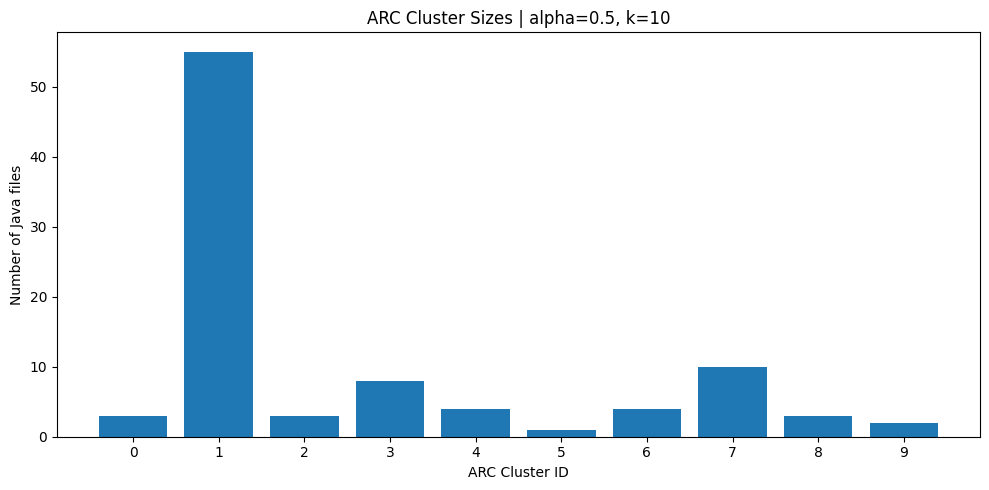

Saved plot: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_cluster_sizes.png


In [22]:
# ============================================================
# CELL 16 — CLUSTER SIZE PLOT
# ============================================================
cluster_sizes = cluster_df.groupby("cluster_id").size().reset_index(name="size")

plt.figure(figsize=(10, 5))
plt.bar(cluster_sizes["cluster_id"].astype(str), cluster_sizes["size"])
plt.xlabel("ARC Cluster ID")
plt.ylabel("Number of Java files")
plt.title(f"ARC Cluster Sizes | alpha={ALPHA}, k={TARGET_NUM_CLUSTERS}")
plt.tight_layout()

plot_path = OUTPUT_DIR / f"{RUN_NAME}_cluster_sizes.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

## Cell 17 — Parse Week 2 cluster files and run sanity comparison

This is **not** a replacement for official ARCADE `a2a` / `cvg`, but it tells you whether the files share enough common entities to compare.

In [23]:
# ============================================================
# CELL 17 — PYTHON SANITY COMPARISON WITH WEEK 2 CLUSTERS
# ============================================================
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def parse_cluster_rsf(path):
    mapping = {}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) >= 3 and parts[0].lower() in {"contain", "contains"}:
                cluster = parts[1]
                entity = normalize_entity_name(parts[2])
                mapping[entity] = cluster
    return mapping

cluster_maps = {}
cluster_maps["ARC_QODO"] = {row["entity"]: f"ARC_Cluster_{int(row['cluster_id'])}" for _, row in cluster_df.iterrows()}

for label, path in BASELINE_CLUSTER_FILES.items():
    cluster_maps[label] = parse_cluster_rsf(path)
    print(f"{label}: {len(cluster_maps[label])} entities parsed")

def compare_cluster_maps(name_a, map_a, name_b, map_b):
    common = sorted(set(map_a.keys()) & set(map_b.keys()))

    if len(common) < 2:
        return {
            "architecture_a": name_a,
            "architecture_b": name_b,
            "entities_a": len(map_a),
            "entities_b": len(map_b),
            "common_entities": len(common),
            "clusters_a_common": None,
            "clusters_b_common": None,
            "adjusted_rand_index": None,
            "normalized_mutual_info": None,
            "note": "Too few common entities for meaningful comparison",
        }

    labels_a_raw = [map_a[e] for e in common]
    labels_b_raw = [map_b[e] for e in common]

    def encode(labels_raw):
        lookup = {}
        encoded = []
        for x in labels_raw:
            if x not in lookup:
                lookup[x] = len(lookup)
            encoded.append(lookup[x])
        return encoded, lookup

    labels_a, lookup_a = encode(labels_a_raw)
    labels_b, lookup_b = encode(labels_b_raw)

    return {
        "architecture_a": name_a,
        "architecture_b": name_b,
        "entities_a": len(map_a),
        "entities_b": len(map_b),
        "common_entities": len(common),
        "clusters_a_common": len(lookup_a),
        "clusters_b_common": len(lookup_b),
        "adjusted_rand_index": adjusted_rand_score(labels_a, labels_b),
        "normalized_mutual_info": normalized_mutual_info_score(labels_a, labels_b),
        "note": "Python sanity check only; use ARCADE a2a/cvg for official evaluation",
    }

names = list(cluster_maps.keys())
comparison_rows = []

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        comparison_rows.append(compare_cluster_maps(names[i], cluster_maps[names[i]], names[j], cluster_maps[names[j]]))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(COMPARISON_CSV_OUT, index=False)

print("Comparison saved:", COMPARISON_CSV_OUT)
comparison_df

WCA_UEM: 343 entities parsed
WCA_UEMNM: 343 entities parsed
LIMBO_IL: 343 entities parsed
Comparison saved: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_python_comparison_sanity.csv


/pc2/users/r/rohit/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
/pc2/users/r/rohit/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


,architecture_a,architecture_b,entities_a,entities_b,common_entities,clusters_a_common,clusters_b_common,adjusted_rand_index,normalized_mutual_info,note
0,ARC_QODO,WCA_UEM,93,343,53,1.0,25.0,0.000000,0.000000,Python sanity check only; use ARCADE a2a/cvg f...
1,ARC_QODO,WCA_UEMNM,93,343,53,1.0,1.0,1.000000,1.000000,Python sanity check only; use ARCADE a2a/cvg f...
2,ARC_QODO,LIMBO_IL,93,343,0,NaN,NaN,NaN,NaN,Too few common entities for meaningful comparison
3,WCA_UEM,WCA_UEMNM,343,343,343,213.0,10.0,0.009432,0.273797,Python sanity check only; use ARCADE a2a/cvg f...
4,WCA_UEM,LIMBO_IL,343,343,0,NaN,NaN,NaN,NaN,Too few common entities for meaningful comparison
5,WCA_UEMNM,LIMBO_IL,343,343,0,NaN,NaN,NaN,NaN,Too few common entities for meaningful comparison


## Cell 18 — Write final summary file

In [24]:
# ============================================================
# CELL 18 — WRITE SUMMARY FILE
# ============================================================
summary_text = f"""
DS4SE26 Week 3 ARC Run Summary
==============================

Working directory:
{WORK_DIR}

Input files:
Focused dependency RSF: {FOCUSED_DEPENDENCY_RSF}
WCA_UEM: {BASELINE_CLUSTER_FILES['WCA_UEM']}
WCA_UEMNM: {BASELINE_CLUSTER_FILES['WCA_UEMNM']}
LIMBO_IL: {BASELINE_CLUSTER_FILES['LIMBO_IL']}

Model:
{EMBEDDING_MODEL_NAME}

Lucene source tag/branch:
{LUCENE_GIT_TAG}

ARC settings:
ALPHA = {ALPHA}
TARGET_NUM_CLUSTERS = {TARGET_NUM_CLUSTERS}
BATCH_SIZE = {BATCH_SIZE}
MAX_TOKENS = {MAX_TOKENS}

Counts:
Java source files used = {len(entities)}
Focused RSF dependency edges = {len(dependency_edges)}
Unique RSF entities = {len(rsf_entities)}
Source entities overlapping with focused RSF = {len(overlap_with_rsf)}

Outputs:
ARC RSF = {ARC_RSF_OUT}
ARC CSV = {ARC_CSV_OUT}
Semantic matrix = {semantic_path}
Structural matrix = {structural_path}
Combined matrix = {combined_path}
Distance matrix = {distance_path}
Comparison sanity CSV = {COMPARISON_CSV_OUT}
Cluster size plot = {plot_path}

Important:
The Python comparison table is only a sanity check.
For official Week 3 evaluation, also run ARCADE a2a and cvg using:
- ARC output
- wca_uem.rsf
- wca_uemnm.rsf
- limbo_il.rsf
"""

SUMMARY_OUT.write_text(summary_text, encoding="utf-8")
print("Summary saved:", SUMMARY_OUT)
print(summary_text)

Summary saved: /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_summary.txt

DS4SE26 Week 3 ARC Run Summary

Working directory:
/pc2/users/r/rohit

Input files:
Focused dependency RSF: /pc2/users/r/rohit/input/lucene-codecs-focused.rsf
WCA_UEM: /pc2/users/r/rohit/input/wca_uem.rsf
WCA_UEMNM: /pc2/users/r/rohit/input/wca_uemnm.rsf
LIMBO_IL: /pc2/users/r/rohit/input/limbo_il.rsf

Model:
Qodo/Qodo-Embed-1-7B

Lucene source tag/branch:
releases/lucene/9.10.0

ARC settings:
ALPHA = 0.5
TARGET_NUM_CLUSTERS = 10
BATCH_SIZE = 2
MAX_TOKENS = 8192

Counts:
Java source files used = 93
Focused RSF dependency edges = 1947
Unique RSF entities = 343
Source entities overlapping with focused RSF = 53

Outputs:
ARC RSF = /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_clusters.rsf
ARC CSV = /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_clusters.csv
Semantic matrix = /pc2/users/r/rohit/output/ARC_Qodo_alpha0_5_k10_semantic_similarity_matrix.npy
Structural matrix = /pc2/users/r/rohit/output/ARC_Qodo_alph

## Cell 19 — Optional: generate Slurm batch script

Use this only if you want to run the notebook-converted `.py` as a normal `sbatch` job later.

In [25]:
# ============================================================
# CELL 19 — OPTIONAL: WRITE SLURM SCRIPT TEMPLATE
# ============================================================
slurm_script = f'''#!/bin/bash
#SBATCH -A hpc-prf-dssecs
#SBATCH -J dsse_w3_arc
#SBATCH --partition=dgx
#SBATCH --qos=devel
#SBATCH --gres=gpu:a100:1
#SBATCH --cpus-per-task=16
#SBATCH --mem=64G
#SBATCH --time=02:00:00
#SBATCH --chdir={WORK_DIR}
#SBATCH -o logs/%x-%j.out
#SBATCH -e logs/%x-%j.err

set -euo pipefail

export PATH="$HOME/.local/bin:$PATH"
export HF_HOME="{CACHE_DIR}/hf_cache"
export HF_HUB_CACHE="$HF_HOME/hub"
export TRANSFORMERS_CACHE="$HF_HOME/transformers"
export TOKENIZERS_PARALLELISM=false

mkdir -p logs output cache

echo "Running on node: $HOSTNAME"
echo "PWD: $(pwd)"
echo "Job ID: $SLURM_JOB_ID"
echo "Start time: $(date)"

nvidia-smi || true
python --version

# Convert notebook manually before using this, e.g.:
# jupyter nbconvert --to python DS4SE26_Week3_ARC_PC2_MultiCell_Fixed.ipynb --output week3_arc_hpc.py

srun python week3_arc_hpc.py

echo "Finished at: $(date)"
'''

script_path = WORK_DIR / "run_week3_arc.sh"
script_path.write_text(slurm_script, encoding="utf-8")
script_path.chmod(0o755)

print("Slurm script written to:", script_path)
print("\nTo use later:")
print("jupyter nbconvert --to python DS4SE26_Week3_ARC_PC2_MultiCell_Fixed.ipynb --output week3_arc_hpc.py")
print("read -s HF_TOKEN")
print("export HF_TOKEN")
print("sbatch --export=ALL,HF_TOKEN run_week3_arc.sh")

Slurm script written to: /pc2/users/r/rohit/run_week3_arc.sh

To use later:
jupyter nbconvert --to python DS4SE26_Week3_ARC_PC2_MultiCell_Fixed.ipynb --output week3_arc_hpc.py
read -s HF_TOKEN
export HF_TOKEN
sbatch --export=ALL,HF_TOKEN run_week3_arc.sh


## Final expected outputs

After Cell 18, check your `output/` folder. The most important file is:

```text
output/ARC_Qodo_alpha0_5_k10_clusters.rsf
```

Also check:

```text
output/ARC_Qodo_alpha0_5_k10_python_comparison_sanity.csv
```

For the final assignment/report, use the official ARCADE `a2a` and `cvg` evaluation again using this new ARC `.rsf` file and your Week 2 `.rsf` files.